# Trabalho 3: Sistema de Suporte à Decisão para Detecção de Intrusões em Redes com IA, Machine Learning e Deep Learning

** **

| Item | Descrição |
|---|---|
| Instituição | Universidade de Brasília (UnB) |
| Unidade | Departamento de Engenharia de Produção |
| Disciplina | Sistemas de Suporte à Decisão (SSD) |
| Professor | André Luiz Marques Serrano |
| Aluna | Giovanna Santiago |
| Tema | Segurança cibernética |
| Plataforma | Google Colab (notebook) + Google Drive (persistência em nuvem) |

** **

Bem-vindo a este notebook. Aqui aplicamos, passo a passo, os conceitos vistos em sala (Inteligência Artificial, Machine Learning e Deep Learning) a um problema real de **segurança cibernética**: decidir, a cada conexão de rede, se ela é **tráfego normal** ou um **ataque**, e qual ação o analista de segurança deve tomar.

O notebook segue a mesma lógica do notebook de aula (bibliotecas, pré-processamento, treinamento, avaliação, Perceptron e rede neural profunda) e a estrutura exigida para o MVP (objetivo, busca, coleta, modelagem, carga, análise e autoavaliação).

> 💡 **Como ler este notebook:** cada etapa tem uma caixa **"Entendendo"** com a explicação em linguagem simples. Se você só quiser a resposta final, vá direto para a seção **12. Discussão geral**.

## Sumário

1. Contexto: IA, ML e DL na segurança cibernética
2. Objetivo e perguntas de negócio
3. Busca pelos dados (busca booleana)
4. Principais bibliotecas
5. Coleta
6. Modelagem e Catálogo de Dados
7. Transformação e carga (ETL)
8. Qualidade dos dados
9. Análise exploratória (P1)
10. Nível IA: regra booleana, Machine Learning e Deep Learning (P2 e P3)
11. Explicabilidade e decisão (P4 e P5)
12. Discussão geral
13. Autoavaliação
14. Referências

## 1. Contexto: IA, ML e DL na segurança cibernética

Em sala vimos que as três áreas são **círculos concêntricos**:

```
┌───────────────────────────────────────────────┐
│  Inteligência Artificial (IA)                 │
│   regras, busca, lógica booleana              │
│   ┌───────────────────────────────────────┐   │
│   │  Machine Learning (ML)                │   │
│   │   aprende regras a partir de dados    │   │
│   │   ┌───────────────────────────────┐   │   │
│   │   │  Deep Learning (DL)           │   │   │
│   │   │   redes neurais com várias    │   │   │
│   │   │   camadas                     │   │   │
│   │   └───────────────────────────────┘   │   │
│   └───────────────────────────────────────┘   │
└───────────────────────────────────────────────┘
```

Neste trabalho vamos **subir um nível de cada vez**, sempre no mesmo problema:

| Nível | O que é | Como aparece neste trabalho |
|---|---|---|
| IA (simbólica) | Um especialista escreve regras do tipo SE ... E ... OU ... ENTÃO | Regra booleana escrita à mão para marcar ataques |
| ML | O algoritmo descobre as regras sozinho olhando exemplos rotulados | Naive Bayes, Regressão Logística, Árvore de Decisão e Random Forest |
| DL | Rede neural com várias camadas que aprende combinações complexas | Perceptron (base) e rede neural profunda (MLP) com TensorFlow/Keras |

**Por que isso é um Sistema de Suporte à Decisão (SSD)?** Uma equipe de segurança (SOC, *Security Operations Center*) recebe milhares de conexões por minuto e não consegue olhar uma por uma. O modelo não substitui o analista: ele **prioriza** o que merece atenção e **sugere uma ação** (bloquear, investigar ou liberar). A decisão final continua humana, mas passa a ser apoiada por dados.

## 2. Objetivo e perguntas de negócio

### 2.1 Problema

Sistemas de detecção de intrusão (IDS) baseados apenas em regras fixas deixam passar ataques novos e geram muitos alarmes falsos. O analista de segurança precisa de uma ferramenta que **classifique conexões automaticamente**, **explique** o que pesou na decisão e **indique o que fazer** considerando que deixar passar um ataque custa muito mais caro do que investigar um alarme falso.

### 2.2 Hipótese do MVP

> Um modelo de aprendizado de máquina treinado com registros históricos de conexões consegue detectar ataques com desempenho superior a uma regra booleana escrita à mão, e uma rede neural profunda consegue generalizar melhor para **tipos de ataque que não existiam no treino**.

**Métrica que confirma ou refuta a hipótese:** *recall* (taxa de detecção) da classe ataque e F1 no conjunto de teste NSL-KDD (KDDTest+), que contém 17 tipos de ataque ausentes no treino. Meta de referência: recall de ataque ≥ 90% com precisão ≥ 90%.

### 2.3 Perguntas de negócio

| # | Pergunta | Decisão que ela apoia |
|---|---|---|
| P1 | Quais categorias de ataque são mais frequentes e quais protocolos e serviços são mais visados? | Onde concentrar monitoramento e regras de firewall |
| P2 | Modelos de ML clássicos detectam ataques em tráfego novo com recall ≥ 90% e precisão ≥ 90%, superando uma regra booleana manual? | Vale a pena trocar regras fixas por um modelo treinado? |
| P3 | Uma rede neural profunda (DL) supera o ML clássico, especialmente nos tipos de ataque **nunca vistos** no treino? | Vale o custo extra de complexidade do Deep Learning? |
| P4 | Quais características da conexão mais pesam na detecção? | Quais indicadores o analista deve olhar primeiro; quais logs coletar |
| P5 | Qual limiar de decisão minimiza o custo esperado dos erros, se deixar passar um ataque custa 10 vezes mais que um alarme falso? | Política de ação: bloquear, investigar ou liberar |

> 📌 Conforme orientação do MVP, as perguntas ficam **intactas** até o final, mesmo que alguma não seja totalmente atingida. O atingimento é discutido na Autoavaliação.

## 3. Busca pelos dados (busca booleana)

A busca por bases e por referências foi feita com **operadores booleanos** (AND, OR, NOT), a mesma lógica que usaremos depois na regra de IA simbólica. As strings usadas no Kaggle, Google Dataset Search e Google Scholar foram:

```
Busca de bases:
("intrusion detection" OR "IDS" OR "network attack") AND ("dataset") AND ("labeled" OR "labelled")

Busca de literatura:
("deep learning" OR "neural network") AND ("intrusion detection") AND ("NSL-KDD") NOT ("IoT")
```

**Entendendo:** `AND` exige que os dois termos apareçam (estreita a busca), `OR` aceita qualquer um deles (amplia a busca) e `NOT` exclui um termo (remove resultados fora do escopo).

### 3.1 Bases candidatas

| Base | Tamanho | Rotulada | Cabe no Colab gratuito | Licença / uso | Decisão |
|---|---|---|---|---|---|
| KDD Cup 99 | ~4,9 milhões de linhas | Sim | Com dificuldade | Uso acadêmico livre | Descartada: 78% de registros duplicados, viés conhecido |
| **NSL-KDD** | 148.517 linhas | Sim | **Sim** | Uso acadêmico livre (UNB/CIC) | **Escolhida** |
| CIC-IDS2017 | ~2,8 milhões de linhas, 8 arquivos | Sim | Parcialmente | Uso acadêmico com citação | Descartada para o MVP: volume alto |
| UNSW-NB15 | ~2,5 milhões de linhas | Sim | Parcialmente | Uso acadêmico com citação | Descartada para o MVP: volume alto |

**Por que NSL-KDD?** É a versão corrigida da KDD Cup 99 (sem duplicatas), é um *benchmark* clássico citado em milhares de artigos (o que permite comparar resultados) e, principalmente, seu conjunto de teste contém **ataques que não aparecem no treino**. Isso simula a vida real, em que o atacante sempre inventa algo novo, e é exatamente o que precisamos para responder P3.

**Licença:** a NSL-KDD é disponibilizada pelo Canadian Institute for Cybersecurity (University of New Brunswick) para pesquisa acadêmica, com pedido de citação de Tavallaee et al. (2009). Por isso **não versionamos os dados brutos** no GitHub: o notebook baixa os arquivos direto da fonte (script de coleta).

**Dados pessoais (LGPD):** a base não contém IPs, nomes ou qualquer identificador pessoal; são apenas estatísticas agregadas de conexões simuladas em laboratório. Não há necessidade de anonimização.

## 4. Principais Bibliotecas

Todas as bibliotecas abaixo estão no **PyPI** (https://pypi.org/), o repositório oficial de pacotes Python, e já vêm instaladas no Google Colab.

| Biblioteca | Para que usamos |
|---|---|
| NumPy | Operações numéricas e vetores |
| Pandas | Leitura, limpeza e transformação dos dados (DataFrames) |
| Matplotlib / Seaborn | Gráficos |
| Scikit-learn | Pré-processamento, modelos de ML, Perceptron, métricas e validação cruzada |
| TensorFlow / Keras | Rede neural profunda (Deep Learning) |
| PyArrow | Salvar os dados tratados em formato Parquet (camada de Data Lake) |

In [1]:
# Importa as bibliotecas usadas ao longo do notebook
import os, time, datetime, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Estilo visual igual ao do notebook de aula
sns.set(style="whitegrid")
COR_NORMAL = 'royalblue'   # tráfego normal
COR_ATAQUE = 'indianred'   # ataque

# Semente para que os resultados sejam reproduzíveis
SEED = 42
np.random.seed(SEED)

print('NumPy', np.__version__, '| Pandas', pd.__version__)

NumPy 2.1.3 | Pandas 2.2.3


## 5. Coleta

Os arquivos são baixados diretamente do espelho público da NSL-KDD no GitHub. Não é necessário *web scraping*: são arquivos texto (CSV sem cabeçalho).

| Arquivo | Conteúdo | Uso neste trabalho |
|---|---|---|
| `KDDTrain+.txt` | 125.973 conexões rotuladas | Treino e validação (divisão 70% / 30%, como em aula) |
| `KDDTest+.txt` | 22.544 conexões rotuladas, com 17 tipos de ataque novos | Teste "do mundo real" |

**Entendendo:** cada linha é **uma conexão de rede** (por exemplo, um acesso a um servidor web). As 41 colunas descrevem a conexão (protocolo, bytes enviados, taxa de erros...) e a coluna `label` diz se foi `normal` ou o nome do ataque.

In [2]:
# Endereços da fonte (espelho público da NSL-KDD)
URL_TREINO = 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt'
URL_TESTE  = 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt'

# Nomes das 41 variáveis + rótulo + nível de dificuldade (documentação oficial da base)
COLUNAS = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]

# Leitura direta da internet para DataFrames
df_treino_bruto = pd.read_csv(URL_TREINO, header=None, names=COLUNAS)
df_teste_bruto  = pd.read_csv(URL_TESTE,  header=None, names=COLUNAS)

# Registro de reprodutibilidade: data, volume e formato
DATA_COLETA = datetime.datetime.now().strftime('%d/%m/%Y %H:%M')
print('Data da coleta:', DATA_COLETA)
print('Formato original: CSV sem cabeçalho (.txt), separador vírgula')
print(f'Treino: {df_treino_bruto.shape[0]:,} linhas x {df_treino_bruto.shape[1]} colunas'.replace(',', '.'))
print(f'Teste : {df_teste_bruto.shape[0]:,} linhas x {df_teste_bruto.shape[1]} colunas'.replace(',', '.'))
df_treino_bruto.head()

Data da coleta: 28/09/2026 20:20
Formato original: CSV sem cabeçalho (.txt), separador vírgula
Treino: 125.973 linhas x 43 colunas
Teste : 22.544 linhas x 43 colunas


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


### 5.1 Persistência em nuvem (Google Drive)

Para que os dados fiquem **efetivamente persistidos na nuvem** (requisito do MVP), a célula abaixo monta o Google Drive e salva os arquivos brutos na pasta `MVP_SSD_Seguranca/bronze`. Se o notebook for executado fora do Colab, ele salva numa pasta local com a mesma estrutura, sem dar erro.

**Entendendo a estrutura em camadas (arquitetura *medallion* de Data Lake):**

| Camada | Conteúdo |
|---|---|
| `bronze` | Dados brutos, exatamente como vieram da fonte |
| `silver` | Dados limpos e com colunas derivadas (categoria de ataque, alvo binário...) |
| `gold` | Resultados prontos para decisão (métricas dos modelos, política de ação) |

In [3]:
# Monta o Google Drive para persistir os dados na nuvem.
try:
    from google.colab import drive
    NO_COLAB = True
except ImportError:
    NO_COLAB = False

if NO_COLAB:
    # Se aparecer uma janela pedindo acesso, clique em "Conectar ao Google Drive" e autorize.
    # Se a montagem falhar, o erro aparece aqui (não seguimos sem salvar na nuvem).
    drive.mount('/content/drive', force_remount=True)
    PASTA_BASE = '/content/drive/MyDrive/MVP_SSD_Seguranca'
    print('Google Drive montado: os dados serão salvos em Meu Drive > MVP_SSD_Seguranca')
else:
    PASTA_BASE = './MVP_SSD_Seguranca'
    print('Fora do Colab: usando pasta local', PASTA_BASE)

for camada in ['bronze', 'silver', 'gold']:
    os.makedirs(f'{PASTA_BASE}/{camada}', exist_ok=True)

# Camada bronze: dados brutos, sem nenhuma alteração
df_treino_bruto.to_csv(f'{PASTA_BASE}/bronze/KDDTrain+.csv', index=False)
df_teste_bruto.to_csv(f'{PASTA_BASE}/bronze/KDDTest+.csv', index=False)

for f in sorted(os.listdir(f'{PASTA_BASE}/bronze')):
    tam = os.path.getsize(f'{PASTA_BASE}/bronze/{f}') / 1e6
    print(f'bronze/{f}: {tam:.1f} MB')

Mounted at /content/drive
Google Drive montado: os dados serão salvos em Meu Drive > MVP_SSD_Seguranca
bronze/KDDTest+.csv: 3.2 MB
bronze/KDDTrain+.csv: 17.6 MB


## 6. Modelagem e Catálogo de Dados

### 6.1 Modelo de dados

Escolhemos o **modelo flat (Data Lake)**: uma única tabela por conceito, em que **cada linha é uma conexão de rede**. Um esquema estrela não traria ganho aqui, porque não há dimensões com hierarquia (não temos cliente, data ou local), e os algoritmos de ML precisam justamente de uma tabela única com uma linha por exemplo.

```
tb_conexoes (camada silver)
├── Identificação ........ id_conexao, origem (treino/teste)
├── Atributos básicos .... duration, protocol_type, service, flag, src_bytes, dst_bytes, land, wrong_fragment, urgent
├── Conteúdo ............. hot, num_failed_logins, logged_in, num_compromised, root_shell, su_attempted, ...
├── Tráfego (2 segundos) . count, srv_count, serror_rate, rerror_rate, same_srv_rate, ...
├── Tráfego (100 conexões) dst_host_count, dst_host_srv_count, dst_host_same_srv_rate, ...
└── Rótulos .............. label, categoria_ataque, alvo (0 normal / 1 ataque), ataque_novo, difficulty
```

**Entendendo os grupos de atributos:** os atributos *básicos* descrevem a conexão isolada; os de *conteúdo* olham dentro dos pacotes (tentativas de login, acesso root); os de *tráfego* olham para o comportamento recente (quantas conexões para o mesmo destino nos últimos 2 segundos ou nas últimas 100 conexões). Ataques de negação de serviço, por exemplo, aparecem como muitas conexões em pouco tempo.

### 6.2 Mapeamento dos ataques em categorias

A base tem dezenas de nomes de ataque. Seguindo a literatura (Tavallaee et al., 2009), agrupamos em 4 categorias:

| Categoria | Significado | Exemplos |
|---|---|---|
| **DoS** (*Denial of Service*) | Derrubar o serviço inundando o servidor | neptune, smurf, back, teardrop, apache2 |
| **Probe** | Varredura para descobrir portas e vulnerabilidades | satan, ipsweep, portsweep, nmap, mscan |
| **R2L** (*Remote to Local*) | Acesso indevido vindo de fora (ex.: adivinhar senha) | guess_passwd, warezmaster, snmpguess |
| **U2R** (*User to Root*) | Usuário comum tentando virar administrador | buffer_overflow, rootkit, perl, sqlattack |

In [4]:
# Dicionário de mapeamento: nome do ataque -> categoria
MAPA_CATEGORIA = {
    'normal': 'Normal',
    # DoS
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS','teardrop':'DoS',
    'apache2':'DoS','mailbomb':'DoS','processtable':'DoS','udpstorm':'DoS',
    # Probe
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe','mscan':'Probe','saint':'Probe',
    # R2L
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L','phf':'R2L','spy':'R2L',
    'warezclient':'R2L','warezmaster':'R2L','sendmail':'R2L','named':'R2L','snmpgetattack':'R2L',
    'snmpguess':'R2L','xlock':'R2L','xsnoop':'R2L','worm':'R2L',
    # U2R
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R','ps':'U2R',
    'sqlattack':'U2R','xterm':'U2R','httptunnel':'U2R',
}

# Verificação: todo rótulo existente precisa ter categoria
rotulos = set(df_treino_bruto['label']) | set(df_teste_bruto['label'])
sem_categoria = rotulos - set(MAPA_CATEGORIA)
print('Rótulos distintos na base:', len(rotulos))
print('Rótulos sem categoria:', sem_categoria if sem_categoria else 'nenhum')

Rótulos distintos na base: 40
Rótulos sem categoria: nenhum


### 6.3 Catálogo de Dados

O catálogo abaixo contém, para cada atributo: **nome, tipo, descrição, domínio** (mínimo e máximo observados para numéricos, lista de categorias para categóricos), **obrigatoriedade** e **linhagem**. Os domínios são calculados diretamente dos dados, para não haver erro de digitação.

In [5]:
# Descrição de cada atributo (documentação da KDD Cup 99 / NSL-KDD, traduzida)
DESCRICOES = {
 'duration':'Duração da conexão em segundos',
 'protocol_type':'Protocolo de transporte (tcp, udp, icmp)',
 'service':'Serviço de destino (http, ftp, smtp, private...)',
 'flag':'Estado final da conexão TCP (SF = normal, S0 = sem resposta, REJ = rejeitada...)',
 'src_bytes':'Bytes enviados da origem para o destino',
 'dst_bytes':'Bytes enviados do destino para a origem',
 'land':'1 se origem e destino têm mesmo IP e porta (sinal de ataque land)',
 'wrong_fragment':'Número de fragmentos de pacote com erro',
 'urgent':'Número de pacotes marcados como urgentes',
 'hot':'Número de indicadores "quentes" (acesso a diretórios de sistema, execução de programas)',
 'num_failed_logins':'Tentativas de login que falharam',
 'logged_in':'1 se o login foi bem-sucedido',
 'num_compromised':'Número de condições de comprometimento detectadas',
 'root_shell':'1 se obteve terminal de administrador (root)',
 'su_attempted':'1 se tentou o comando su (trocar para root)',
 'num_root':'Número de acessos como root',
 'num_file_creations':'Número de arquivos criados',
 'num_shells':'Número de terminais abertos',
 'num_access_files':'Operações em arquivos de controle de acesso',
 'num_outbound_cmds':'Comandos de saída em sessões FTP',
 'is_host_login':'1 se o login pertence à lista de hosts',
 'is_guest_login':'1 se o login foi como convidado (guest)',
 'count':'Conexões para o mesmo host nos últimos 2 segundos',
 'srv_count':'Conexões para o mesmo serviço nos últimos 2 segundos',
 'serror_rate':'% de conexões com erro SYN (mesmo host, 2 s)',
 'srv_serror_rate':'% de conexões com erro SYN (mesmo serviço, 2 s)',
 'rerror_rate':'% de conexões rejeitadas REJ (mesmo host, 2 s)',
 'srv_rerror_rate':'% de conexões rejeitadas REJ (mesmo serviço, 2 s)',
 'same_srv_rate':'% de conexões para o mesmo serviço (mesmo host, 2 s)',
 'diff_srv_rate':'% de conexões para serviços diferentes (mesmo host, 2 s)',
 'srv_diff_host_rate':'% de conexões para hosts diferentes (mesmo serviço, 2 s)',
 'dst_host_count':'Conexões para o mesmo host de destino (últimas 100 conexões)',
 'dst_host_srv_count':'Conexões para o mesmo serviço de destino (últimas 100)',
 'dst_host_same_srv_rate':'% para o mesmo serviço (últimas 100, mesmo host)',
 'dst_host_diff_srv_rate':'% para serviços diferentes (últimas 100, mesmo host)',
 'dst_host_same_src_port_rate':'% com a mesma porta de origem (últimas 100)',
 'dst_host_srv_diff_host_rate':'% para hosts diferentes (últimas 100, mesmo serviço)',
 'dst_host_serror_rate':'% com erro SYN (últimas 100, mesmo host)',
 'dst_host_srv_serror_rate':'% com erro SYN (últimas 100, mesmo serviço)',
 'dst_host_rerror_rate':'% rejeitadas REJ (últimas 100, mesmo host)',
 'dst_host_srv_rerror_rate':'% rejeitadas REJ (últimas 100, mesmo serviço)',
 'label':'Rótulo original: normal ou nome do ataque',
 'difficulty':'Nível de dificuldade do registro (quantos de 21 classificadores de referência acertaram)',
}

BINARIOS = ['land','logged_in','root_shell','is_host_login','is_guest_login']
CATEGORICOS = ['protocol_type','service','flag','label']

df_todos = pd.concat([df_treino_bruto, df_teste_bruto])
linhas = []
for col in COLUNAS:
    s = df_todos[col]
    if col in CATEGORICOS:
        tipo = 'categórico'
        cats = sorted(s.unique())
        dominio = f'{len(cats)} categorias: ' + ', '.join(cats[:6]) + (' ...' if len(cats) > 6 else '')
    elif col in BINARIOS:
        tipo = 'booleano (0/1)'
        dominio = '{' + ', '.join(str(v) for v in sorted(s.unique())) + '}'
    elif col.endswith('rate'):
        tipo = 'numérico (proporção)'
        dominio = f'{s.min():g} a {s.max():g} (esperado 0 a 1)'
    else:
        tipo = 'numérico (inteiro)'
        dominio = f'{s.min():,.0f} a {s.max():,.0f}'.replace(',', '.')
    linhas.append({
        'atributo': col, 'tipo': tipo, 'descrição': DESCRICOES[col], 'domínio': dominio,
        'obrigatório': 'Sim (não admite nulo)',
        'linhagem': 'NSL-KDD (CIC/UNB), KDDTrain+/KDDTest+, coletado em ' + DATA_COLETA.split()[0],
    })

catalogo = pd.DataFrame(linhas)

# Atributos derivados criados na etapa de transformação (seção 7)
derivados = pd.DataFrame([
  {'atributo':'categoria_ataque','tipo':'categórico','descrição':'Grupo do ataque','domínio':'Normal, DoS, Probe, R2L, U2R','obrigatório':'Sim','linhagem':'Derivado de label via MAPA_CATEGORIA'},
  {'atributo':'alvo','tipo':'booleano (0/1)','descrição':'Variável que o modelo prevê: 0 normal, 1 ataque','domínio':'{0, 1}','obrigatório':'Sim','linhagem':'Derivado de label (label != normal)'},
  {'atributo':'ataque_novo','tipo':'booleano (0/1)','descrição':'1 se o tipo de ataque não existe no treino','domínio':'{0, 1}','obrigatório':'Sim','linhagem':'Comparação entre rótulos do teste e do treino'},
  {'atributo':'origem','tipo':'categórico','descrição':'Arquivo de origem do registro','domínio':'treino, teste','obrigatório':'Sim','linhagem':'Nome do arquivo de coleta'},
])
catalogo = pd.concat([catalogo, derivados], ignore_index=True)

pd.set_option('display.max_colwidth', 90)
pd.set_option('display.max_rows', 60)
catalogo

,atributo,tipo,descrição,domínio,obrigatório,linhagem
0,duration,numérico (inteiro),Duração da conexão em segundos,0 a 57.715,Sim (não admite nulo),"NSL-KDD (CIC/UNB), KDDTrain+/KDDTest+, coletado em 28/09/2026"
1,protocol_type,categórico,"Protocolo de transporte (tcp, udp, icmp)","3 categorias: icmp, tcp, udp",Sim (não admite nulo),"NSL-KDD (CIC/UNB), KDDTrain+/KDDTest+, coletado em 28/09/2026"
2,service,categórico,"Serviço de destino (http, ftp, smtp, private...)","70 categorias: IRC, X11, Z39_50, aol, auth, bgp ...",Sim (não admite nulo),"NSL-KDD (CIC/UNB), KDDTrain+/KDDTest+, coletado em 28/09/2026"
3,flag,categórico,"Estado final da conexão TCP (SF = normal, S0 = sem resposta, REJ = rejeitada...)","11 categorias: OTH, REJ, RSTO, RSTOS0, RSTR, S0 ...",Sim (não admite nulo),"NSL-KDD (CIC/UNB), KDDTrain+/KDDTest+, coletado em 28/09/2026"
4,src_bytes,numérico (inteiro),Bytes enviados da origem para o destino,0 a 1.379.963.888,Sim (não admite nulo),"NSL-KDD (CIC/UNB), KDDTrain+/KDDTest+, coletado em 28/09/2026"
5,dst_bytes,numérico (inteiro),Bytes enviados do destino para a origem,0 a 1.309.937.401,Sim (não admite nulo),"NSL-KDD (CIC/UNB), KDDTrain+/KDDTest+, coletado em 28/09/2026"
6,land,booleano (0/1),1 se origem e destino têm mesmo IP e porta (sinal de ataque land),"{0, 1}",Sim (não admite nulo),"NSL-KDD (CIC/UNB), KDDTrain+/KDDTest+, coletado em 28/09/2026"
7,wrong_fragment,numérico (inteiro),Número de fragmentos de pacote com erro,0 a 3,Sim (não admite nulo),"NSL-KDD (CIC/UNB), KDDTrain+/KDDTest+, coletado em 28/09/2026"
8,urgent,numérico (inteiro),Número de pacotes marcados como urgentes,0 a 3,Sim (não admite nulo),"NSL-KDD (CIC/UNB), KDDTrain+/KDDTest+, coletado em 28/09/2026"
9,hot,numérico (inteiro),"Número de indicadores ""quentes"" (acesso a diretórios de sistema, execução de programas)",0 a 101,Sim (não admite nulo),"NSL-KDD (CIC/UNB), KDDTrain+/KDDTest+, coletado em 28/09/2026"


## 7. Transformação e carga (ETL)

**ETL** significa *Extract, Transform, Load*: extraímos (seção 5), transformamos (aqui) e carregamos na camada `silver` do Data Lake.

### Regras de negócio aplicadas na transformação

| # | Regra | Por quê |
|---|---|---|
| R1 | Criar `categoria_ataque` a partir de `label` | Permite análise por tipo de ameaça (P1) |
| R2 | Criar `alvo` = 1 se `label` ≠ normal, senão 0 | O problema de decisão é binário: é ou não é ataque |
| R3 | Criar `ataque_novo` = 1 se o tipo de ataque do teste não aparece no treino | Mede a generalização para ameaças desconhecidas (P3) |
| R4 | Remover `num_outbound_cmds` | Coluna constante (sempre 0): não carrega informação (ver seção 8) |
| R5 | Aplicar `log(1 + x)` em `duration`, `src_bytes` e `dst_bytes` | Esses valores vão de 0 a bilhões; o log "encolhe" a escala e evita que poucos valores gigantes dominem o modelo |
| R6 | `difficulty` **não** entra como variável explicativa | É metadado de avaliação da base, não existe numa conexão real (usar causaria vazamento de informação) |
| R7 | Remover duplicatas exatas, se houver | Evita que o mesmo exemplo conte duas vezes |

In [6]:
def transformar(df, origem, rotulos_treino):
    # Aplica as regras R1 a R7 e devolve a tabela da camada silver
    d = df.copy()
    d['origem'] = origem
    d['categoria_ataque'] = d['label'].map(MAPA_CATEGORIA)                       # R1
    d['alvo'] = (d['label'] != 'normal').astype(int)                             # R2
    d['ataque_novo'] = ((d['alvo'] == 1) & (~d['label'].isin(rotulos_treino))).astype(int)  # R3
    d = d.drop(columns=['num_outbound_cmds'])                                    # R4
    for c in ['duration', 'src_bytes', 'dst_bytes']:                             # R5
        d[c] = np.log1p(d[c])
    antes = len(d)
    d = d.drop_duplicates()                                                      # R7
    print(f'{origem}: {antes - len(d)} duplicatas removidas')
    return d

rotulos_treino = set(df_treino_bruto['label'])
silver_treino = transformar(df_treino_bruto, 'treino', rotulos_treino)
silver_teste  = transformar(df_teste_bruto,  'teste',  rotulos_treino)

# Carga na camada silver (Parquet: formato colunar, compacto e com tipos preservados)
tb_conexoes = pd.concat([silver_treino, silver_teste], ignore_index=True)
tb_conexoes.insert(0, 'id_conexao', range(1, len(tb_conexoes) + 1))
tb_conexoes.to_parquet(f'{PASTA_BASE}/silver/tb_conexoes.parquet', index=False)
catalogo.to_csv(f'{PASTA_BASE}/silver/catalogo_dados.csv', index=False)

# Conferência da carga: relemos o arquivo salvo e comparamos
conferencia = pd.read_parquet(f'{PASTA_BASE}/silver/tb_conexoes.parquet')
print('Linhas carregadas:', len(conferencia), '| iguais ao DataFrame em memória:', conferencia.shape == tb_conexoes.shape)
print('Tipos de ataque presentes só no teste:', sorted(silver_teste.loc[silver_teste.ataque_novo == 1, 'label'].unique()))

treino: 0 duplicatas removidas
teste: 0 duplicatas removidas
Linhas carregadas: 148517 | iguais ao DataFrame em memória: True
Tipos de ataque presentes só no teste: ['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


## 8. Qualidade dos dados

Avaliamos as dimensões pedidas no MVP para **cada atributo**:

| Dimensão | Pergunta | Como verificamos |
|---|---|---|
| Completude | Há valores nulos? | Contagem de nulos por coluna |
| Unicidade | Há linhas duplicadas? | `duplicated()` |
| Conformidade | Os valores respeitam o domínio? | Taxas entre 0 e 1; binários só 0 ou 1; categorias válidas |
| Consistência | Há contradições entre atributos? | Ex.: `srv_count` não pode ser maior que 0 se `count` é 0; `root_shell` = 1 exige `logged_in` = 1 |
| Acurácia | Há valores implausíveis? | Bytes negativos, duração negativa |
| Variabilidade | Alguma coluna é constante? | Número de valores distintos |
| Balanceamento | As classes estão equilibradas? | Proporção normal / ataque |

In [7]:
bruto = pd.concat([df_treino_bruto.assign(origem='treino'), df_teste_bruto.assign(origem='teste')])
num_cols = [c for c in COLUNAS if c not in CATEGORICOS]

qualidade = pd.DataFrame({
    'nulos': bruto[COLUNAS].isna().sum(),
    'distintos': bruto[COLUNAS].nunique(),
    'mínimo': bruto[COLUNAS].min(numeric_only=False),
    'máximo': bruto[COLUNAS].max(numeric_only=False),
})
qualidade['constante'] = qualidade['distintos'] == 1

taxas = [c for c in COLUNAS if c.endswith('rate')]
qualidade['fora_do_domínio'] = 0
for c in taxas:
    qualidade.loc[c, 'fora_do_domínio'] = int(((bruto[c] < 0) | (bruto[c] > 1)).sum())
for c in BINARIOS:
    qualidade.loc[c, 'fora_do_domínio'] = int((~bruto[c].isin([0, 1])).sum())
for c in ['duration', 'src_bytes', 'dst_bytes']:
    qualidade.loc[c, 'fora_do_domínio'] = int((bruto[c] < 0).sum())

qualidade

,nulos,distintos,mínimo,máximo,constante,fora_do_domínio
duration,0,3424,0,57715,False,0
protocol_type,0,3,icmp,udp,False,0
service,0,70,IRC,whois,False,0
flag,0,11,OTH,SH,False,0
src_bytes,0,3601,0,1379963888,False,0
dst_bytes,0,10401,0,1309937401,False,0
land,0,2,0,1,False,0
wrong_fragment,0,3,0,3,False,0
urgent,0,4,0,3,False,0
hot,0,29,0,101,False,0


In [8]:
print('=== Resumo da qualidade ===')
print('Total de nulos em toda a base:', int(bruto[COLUNAS].isna().sum().sum()))
print('Duplicatas no treino:', int(df_treino_bruto.duplicated().sum()), '| no teste:', int(df_teste_bruto.duplicated().sum()))
print('Colunas constantes:', list(qualidade.index[qualidade['constante']]))
print('Valores fora do domínio:', int(qualidade['fora_do_domínio'].sum()))

# Consistência entre atributos
inc1 = int(((bruto['count'] == 0) & (bruto['srv_count'] > 0)).sum())
inc2 = int(((bruto['root_shell'] == 1) & (bruto['logged_in'] == 0)).sum())
print('Inconsistência count = 0 e srv_count > 0:', inc1)
print('Inconsistência root_shell = 1 sem logged_in:', inc2)

# Valores binários que não são 0/1
print('su_attempted valores:', sorted(bruto['su_attempted'].unique()))

=== Resumo da qualidade ===
Total de nulos em toda a base: 0
Duplicatas no treino: 0 | no teste: 0
Colunas constantes: ['num_outbound_cmds']
Valores fora do domínio: 0
Inconsistência count = 0 e srv_count > 0: 0
Inconsistência root_shell = 1 sem logged_in: 0
su_attempted valores: [np.int64(0), np.int64(1), np.int64(2)]


**Entendendo o resultado da qualidade:**

* **Completude e unicidade:** a NSL-KDD já é uma base curada (foi criada justamente para corrigir as duplicatas da KDD Cup 99), então não esperamos nulos nem duplicatas, e a verificação acima confirma isso.
* **Coluna constante:** `num_outbound_cmds` é sempre 0. Uma coluna que nunca varia não ajuda a distinguir nada, por isso foi removida (regra R4).
* **`su_attempted`:** a documentação diz que é 0/1, mas aparecem valores 2 (a tabela acima mostra 3 valores distintos). Isso indica que o campo na prática é uma contagem. Como não afeta as perguntas, mantemos o valor e registramos a observação no catálogo.
* **Consistência e acurácia:** não foram encontradas contradições entre atributos (nenhuma conexão com `srv_count` > 0 e `count` = 0, nenhum `root_shell` sem login) nem valores negativos ou taxas fora de 0 a 1.
* **Escala:** `src_bytes` chega a mais de 1 bilhão enquanto as taxas vão de 0 a 1. Por isso aplicamos o log (R5) e depois a padronização (seção 10).

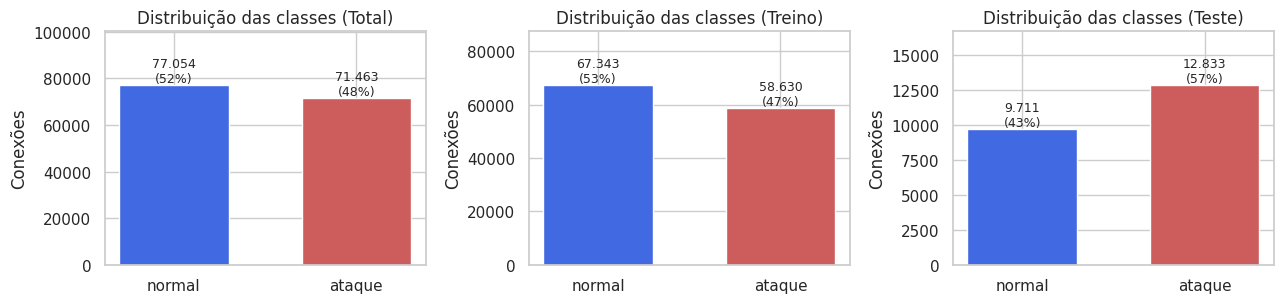

In [9]:
# Balanceamento das classes (mesma visualização do notebook de aula: total, treino e teste)
fig, axs = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, (nome, base) in zip(axs, [('Total', tb_conexoes), ('Treino', silver_treino), ('Teste', silver_teste)]):
    cont = base['alvo'].map({0: 'normal', 1: 'ataque'}).value_counts().reindex(['normal', 'ataque'])
    ax.bar(cont.index, cont.values, color=[COR_NORMAL, COR_ATAQUE], width=0.6)
    for i, v in enumerate(cont.values):
        ax.text(i, v, f'{v:,}\n({v/cont.sum():.0%})'.replace(',', '.'), ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Distribuição das classes ({nome})')
    ax.set_ylabel('Conexões')
    ax.set_ylim(0, cont.max() * 1.3)
plt.tight_layout()
plt.show()

## 9. Análise exploratória

### P1. Quais categorias de ataque são mais frequentes e quais protocolos e serviços são mais visados?

Ataques por categoria


origem,treino,teste,% no treino,% no teste
categoria_ataque,,,,
DoS,45927,7458,78.3,58.1
Probe,11656,2421,19.9,18.9
R2L,995,2754,1.7,21.5
U2R,52,200,0.1,1.6


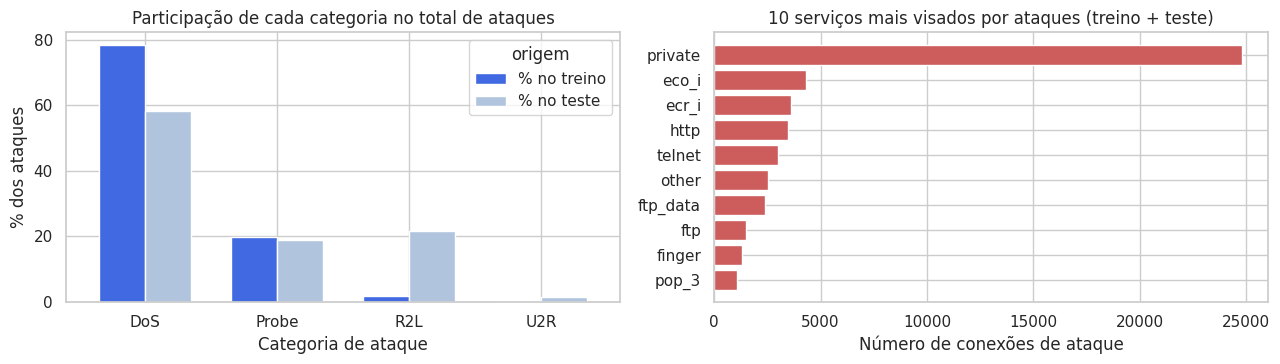

In [10]:
ordem_cat = ['DoS', 'Probe', 'R2L', 'U2R']
ataques = tb_conexoes[tb_conexoes['alvo'] == 1]

tab_cat = (ataques.groupby(['categoria_ataque', 'origem']).size()
           .unstack().reindex(ordem_cat)[['treino', 'teste']])
tab_cat['% no treino'] = (tab_cat['treino'] / tab_cat['treino'].sum() * 100).round(1)
tab_cat['% no teste'] = (tab_cat['teste'] / tab_cat['teste'].sum() * 100).round(1)
print('Ataques por categoria')
display(tab_cat)

fig, axs = plt.subplots(1, 2, figsize=(13, 3.8))
tab_cat[['% no treino', '% no teste']].plot(kind='bar', ax=axs[0], color=['royalblue', 'lightsteelblue'], width=0.7, rot=0)
axs[0].set_title('Participação de cada categoria no total de ataques')
axs[0].set_xlabel('Categoria de ataque')
axs[0].set_ylabel('% dos ataques')

top_servicos = ataques['service'].value_counts().head(10).sort_values()
axs[1].barh(top_servicos.index, top_servicos.values, color=COR_ATAQUE)
axs[1].set_title('10 serviços mais visados por ataques (treino + teste)')
axs[1].set_xlabel('Número de conexões de ataque')
plt.tight_layout()
plt.show()

In [11]:
# Protocolo x classe: qual protocolo concentra ataques?
prot = pd.crosstab(tb_conexoes['protocol_type'], tb_conexoes['categoria_ataque'], normalize='index') * 100
prot = prot[['Normal'] + ordem_cat].round(1)
print('Composição do tráfego por protocolo (% das conexões de cada protocolo)')
display(prot)

# Estado da conexão (flag) nos ataques DoS
print('\nFlags mais comuns em ataques DoS:')
print(ataques[ataques.categoria_ataque == 'DoS']['flag'].value_counts(normalize=True).head(4).mul(100).round(1).astype(str) + ' %')

Composição do tráfego por protocolo (% das conexões de cada protocolo)


categoria_ataque,Normal,DoS,Probe,R2L,U2R
protocol_type,,,,,
icmp,15.0,38.1,46.9,0.0,0.0
tcp,50.5,40.2,6.4,2.7,0.2
udp,80.7,5.1,11.2,2.9,0.0



Flags mais comuns em ataques DoS:
flag
S0      67.7 %
REJ     15.8 %
SF      11.9 %
RSTO     3.0 %
Name: proportion, dtype: object


In [12]:
# Taxa de ataque "novo" por categoria no teste (base para P3)
novos = silver_teste[silver_teste.alvo == 1].groupby('categoria_ataque')['ataque_novo'].mean().reindex(ordem_cat) * 100
print('% dos ataques do TESTE que são de tipos nunca vistos no treino:')
print(novos.round(1).astype(str) + ' %')
print('\nNo total:', f"{silver_teste[silver_teste.alvo == 1]['ataque_novo'].mean():.1%}", 'dos ataques do teste são de tipos novos')

% dos ataques do TESTE que são de tipos nunca vistos no treino:
categoria_ataque
DoS      23.0 %
Probe    54.3 %
R2L      20.2 %
U2R      81.5 %
Name: ataque_novo, dtype: object

No total: 29.2% dos ataques do teste são de tipos novos


**Entendendo P1:**

* **DoS domina** o volume de ataques: são ataques "barulhentos", com muitas conexões em pouco tempo (por isso o volume é grande).
* O serviço **`private`** (portas não padronizadas) concentra de longe o maior volume de ataques, seguido por **`eco_i`/`ecr_i`** (pedidos de *ping*, usados em varreduras) e **`http`**. Os ataques DoS aparecem sobretudo com *flag* **S0** (cerca de 2 em cada 3) (o servidor recebe o pedido de conexão e o atacante nunca completa o "aperto de mão" TCP, esgotando os recursos: é o clássico *SYN flood*).
* **ICMP** tem proporção de ataques muito maior que TCP e UDP (varreduras tipo *ping sweep* e ataques *smurf*).
* **Mudança importante entre treino e teste:** no teste, R2L sobe muito de participação e boa parte dos ataques R2L e U2R são de **tipos novos**. Isso já antecipa o desafio: um modelo que aprendeu muito bem o treino pode tropeçar justamente onde o atacante é mais "criativo".

**Decisão apoiada:** priorizar monitoramento de conexões com flag S0 e rajadas em serviços `private`/`http` (DoS e Probe) e reforçar controles de autenticação (R2L), que são menos volumosos mas mais difíceis de detectar.

## 10. Do nível IA ao Deep Learning

### 10.1 Pré-processamento (preparação dos dados)

Assim como no notebook de aula, dividimos a base de treino em **70% para treinamento e 30% para validação**. A base `KDDTest+` fica guardada como **teste final**, simulando o tráfego de um "mês novo" que o modelo nunca viu.

Os algoritmos só entendem números, então:

* **Variáveis categóricas** (`protocol_type`, `service`, `flag`) viram colunas 0/1 com *One-Hot Encoding*. Exemplo: `protocol_type = tcp` vira `tcp=1, udp=0, icmp=0`.
* **Variáveis numéricas** são **padronizadas** (média 0 e desvio 1) com `StandardScaler`, igual ao feito no Perceptron em aula.

> ⚠️ O `fit` do pré-processamento é feito **somente no treino**. Se usássemos o teste para calcular médias, estaríamos "espiando a prova", o que infla artificialmente os resultados (vazamento de dados).

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

CAT_FEATS = ['protocol_type', 'service', 'flag']
NAO_FEATS = ['label', 'difficulty', 'origem', 'categoria_ataque', 'alvo', 'ataque_novo']
NUM_FEATS = [c for c in silver_treino.columns if c not in CAT_FEATS + NAO_FEATS]

# Divisão 70% treino / 30% validação, estratificada (mantém a proporção de ataques)
df_tr, df_val = train_test_split(silver_treino, test_size=0.3, random_state=SEED, stratify=silver_treino['alvo'])
df_te = silver_teste.copy()

preproc = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATS),  # serviço novo no teste vira tudo 0
    ('num', StandardScaler(), NUM_FEATS),
])
X_tr  = preproc.fit_transform(df_tr).astype('float32')
X_val = preproc.transform(df_val).astype('float32')
X_te  = preproc.transform(df_te).astype('float32')
y_tr, y_val, y_te = df_tr['alvo'].values, df_val['alvo'].values, df_te['alvo'].values
nomes_features = list(preproc.get_feature_names_out())

print('Treino    :', X_tr.shape, '| % ataque', f'{y_tr.mean():.1%}')
print('Validação :', X_val.shape, '| % ataque', f'{y_val.mean():.1%}')
print('Teste     :', X_te.shape, '| % ataque', f'{y_te.mean():.1%}')

Treino    : (88181, 119) | % ataque 46.5%
Validação : (37792, 119) | % ataque 46.5%
Teste     : (22544, 119) | % ataque 56.9%


### 10.2 Avaliação: como vamos medir

Usaremos as mesmas métricas do notebook de aula. No contexto de segurança, **a classe positiva é "ataque"**:

| Métrica | Pergunta que responde em segurança |
|---|---|
| **Recall (revocação)** | De todos os ataques que aconteceram, quantos o sistema pegou? (o mais importante: ataque não detectado é invasão) |
| **Precisão** | De todos os alarmes que o sistema deu, quantos eram ataques de verdade? (precisão baixa = equipe afogada em alarmes falsos) |
| **F1-Score** | Equilíbrio entre recall e precisão |
| **Acurácia** | % total de acertos (pode enganar se as classes forem desequilibradas) |

Na **matriz de confusão**: Falso Negativo (FN) = ataque que passou despercebido; Falso Positivo (FP) = alarme falso.

A função abaixo centraliza a avaliação para compararmos todos os modelos na mesma régua.

In [14]:
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score)

resultados = []   # tabela comparativa final

def avaliar(nome, y_true, y_pred, y_score=None, conjunto='teste', guardar=True):
    linha = {
        'modelo': nome, 'conjunto': conjunto,
        'acurácia': accuracy_score(y_true, y_pred),
        'precisão': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, y_score) if y_score is not None else np.nan,
    }
    if guardar:
        resultados.append(linha)
    return linha

def plot_matriz(y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred)
    labels = ['normal', 'ataque']
    plt.figure(figsize=(5, 3.6))
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=False)
    plt.xlabel('Previsto')
    plt.ylabel('Verdadeiro')
    plt.title(titulo)
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f'Ataques não detectados (FN): {fn:,} | Alarmes falsos (FP): {fp:,}'.replace(',', '.'))

### 10.3 Nível IA: regra booleana escrita por um especialista

Antes de usar aprendizado de máquina, vamos fazer o que um IDS tradicional faz: **um especialista escreve regras**. Usamos a mesma lógica booleana da busca (seção 3), agora aplicada às conexões:

```
SE   (serror_rate > 0,8)                               → muitas conexões sem resposta: SYN flood (DoS)
OU   (count > 100 E same_srv_rate < 0,2)               → rajada para vários serviços: varredura (Probe)
OU   (num_failed_logins > 0)                           → tentativa de senha errada (R2L)
OU   (root_shell = 1 OU su_attempted > 0)              → tentativa de virar administrador (U2R)
OU   (wrong_fragment > 0 OU land = 1)                  → pacotes malformados (DoS clássico)
ENTÃO ataque
SENÃO normal
```

Isso é **Inteligência Artificial simbólica**: há "inteligência" (conhecimento do especialista), mas **nenhum aprendizado** a partir de dados.

Regra booleana no TESTE: {'acurácia': 0.714, 'precisão': 0.981, 'recall': 0.507, 'f1': 0.669}


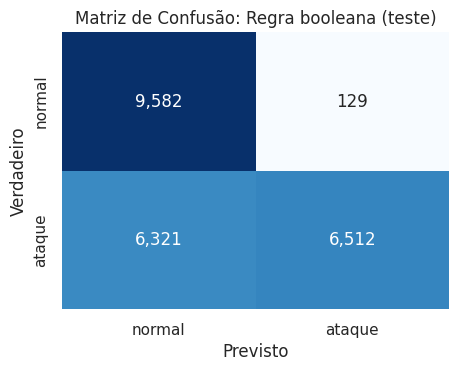

Ataques não detectados (FN): 6.321 | Alarmes falsos (FP): 129


In [15]:
def regra_booleana(df):
    # Regra escrita à mão, usando os valores originais (antes da padronização)
    return (
        (df['serror_rate'] > 0.8)
        | ((df['count'] > 100) & (df['same_srv_rate'] < 0.2))
        | (df['num_failed_logins'] > 0)
        | ((df['root_shell'] == 1) | (df['su_attempted'] > 0))
        | ((df['wrong_fragment'] > 0) | (df['land'] == 1))
    ).astype(int)

pred_regra_val = regra_booleana(df_val)
pred_regra_te = regra_booleana(df_te)

avaliar('Regra booleana (IA)', y_val, pred_regra_val, conjunto='validação')
r = avaliar('Regra booleana (IA)', y_te, pred_regra_te)
print('Regra booleana no TESTE:', {k: round(v, 3) for k, v in r.items() if isinstance(v, float) and not np.isnan(v)})
plot_matriz(y_te, pred_regra_te, 'Matriz de Confusão: Regra booleana (teste)')

**Entendendo:** a regra acerta quase tudo o que ela marca (precisão alta), mas deixa passar muitos ataques (recall baixo), porque o especialista só escreveu regras para os padrões que ele conhece. Todo ataque que não se encaixa nas cinco regras passa direto. É exatamente a limitação que motivou o uso de Machine Learning.

### 10.4 Nível ML: algoritmos de classificação

Vamos treinar os algoritmos apresentados em aula. Cada um "aprende" a regra de decisão sozinho a partir dos 88 mil exemplos de treino:

* **Naive Bayes:** probabilístico, baseado no Teorema de Bayes; rápido, supõe que as variáveis são independentes.
* **Regressão Logística:** calcula a probabilidade de ser ataque a partir de uma combinação linear das variáveis.
* **Árvore de Decisão:** aprende perguntas do tipo "serror_rate > 0,5?" em sequência. Parece a nossa regra booleana, mas **descoberta automaticamente**.
* **Random Forest:** várias árvores votando juntas; reduz o overfitting de uma árvore sozinha.

In [16]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

modelos_ml = {
    'Naive Bayes': GaussianNB(),
    'Regressão Logística': LogisticRegression(max_iter=2000, random_state=SEED),
    'Árvore de Decisão': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED),
}

prob_teste = {}   # probabilidades no teste, guardadas para P3 e P5
for nome, clf in modelos_ml.items():
    t0 = time.time()
    clf.fit(X_tr, y_tr)                                  # Treinamento
    tempo = time.time() - t0
    # Desempenho no treino, validação e teste (para diagnosticar overfitting)
    for conj, X, y in [('treino', X_tr, y_tr), ('validação', X_val, y_val), ('teste', X_te, y_te)]:
        proba = clf.predict_proba(X)[:, 1]
        avaliar(nome, y, (proba >= 0.5).astype(int), proba, conjunto=conj)
    prob_teste[nome] = clf.predict_proba(X_te)[:, 1]
    print(f'{nome:<22} treinado em {tempo:5.1f} s')

tab = pd.DataFrame(resultados)
tab[tab.modelo.isin(modelos_ml)].pivot_table(index='modelo', columns='conjunto', values='f1')[['treino', 'validação', 'teste']].round(3)

Naive Bayes            treinado em   0.1 s
Regressão Logística    treinado em   6.1 s
Árvore de Decisão      treinado em   1.3 s
Random Forest          treinado em   9.6 s


conjunto,treino,validação,teste
modelo,,,
Naive Bayes,0.825,0.822,0.400
Random Forest,1.000,0.999,0.748
Regressão Logística,0.973,0.971,0.739
Árvore de Decisão,1.000,0.998,0.822


**Entendendo a tabela (F1 por conjunto):** na **validação** (mesmo "tipo" de tráfego do treino) os modelos ficam próximos de 99%, mas no **teste** o desempenho cai bastante. Isso **não** é apenas o overfitting clássico visto em aula (decorar o treino): é uma **mudança de distribuição**. O teste traz ataques de tipos novos e um perfil de tráfego diferente. Em segurança, isso é a regra, não a exceção: o atacante muda de tática.

#### 10.4.1 Validação Cruzada

Para garantir que o bom resultado na validação não foi "sorte" de uma divisão específica, aplicamos a **validação cruzada com 5 dobras** (*5-fold*), como apresentado em aula: o treino é dividido em 5 partes, o modelo treina em 4 e testa na 5ª, repetindo 5 vezes.

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
linhas_cv = []
for nome, clf in modelos_ml.items():
    notas = cross_val_score(clf, X_tr, y_tr, cv=cv, scoring='f1', n_jobs=1)
    linhas_cv.append({'modelo': nome, 'F1 médio': notas.mean(), 'desvio padrão': notas.std(),
                      'mín': notas.min(), 'máx': notas.max()})
tab_cv = pd.DataFrame(linhas_cv).set_index('modelo').round(4)
tab_cv

,F1 médio,desvio padrão,mín,máx
modelo,,,,
Naive Bayes,0.8262,0.0038,0.8221,0.8316
Regressão Logística,0.9722,0.0013,0.9703,0.9741
Árvore de Decisão,0.9976,0.0003,0.9970,0.9981
Random Forest,0.9985,0.0001,0.9984,0.9987


**Entendendo:** o desvio padrão muito pequeno entre as 5 dobras mostra que os modelos são **estáveis** dentro da distribuição de treino. Portanto, a queda no teste não vem de instabilidade: vem do fato de o teste ser um "mundo diferente". A validação cruzada responde "o modelo é consistente?", mas **não** responde "o modelo vai funcionar contra ataques novos?". Só o teste separado responde isso.

Melhor modelo de ML no teste (F1): Árvore de Decisão


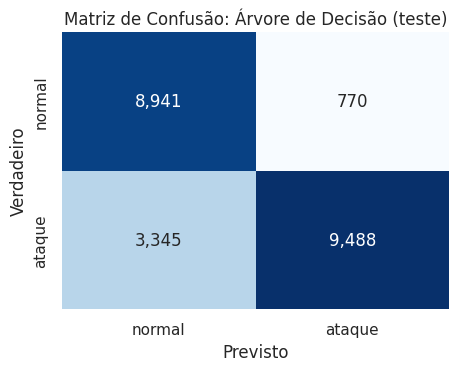

Ataques não detectados (FN): 3.345 | Alarmes falsos (FP): 770
              precision    recall  f1-score   support

      normal      0.728     0.921     0.813      9711
      ataque      0.925     0.739     0.822     12833

    accuracy                          0.817     22544
   macro avg      0.826     0.830     0.817     22544
weighted avg      0.840     0.817     0.818     22544



In [18]:
# Matriz de confusão e relatório do melhor modelo de ML no teste
melhor_ml = tab[(tab.conjunto == 'teste') & (tab.modelo.isin(modelos_ml))].sort_values('f1', ascending=False).iloc[0]['modelo']
print('Melhor modelo de ML no teste (F1):', melhor_ml)
pred_melhor_ml = (prob_teste[melhor_ml] >= 0.5).astype(int)
plot_matriz(y_te, pred_melhor_ml, f'Matriz de Confusão: {melhor_ml} (teste)')
print(classification_report(y_te, pred_melhor_ml, target_names=['normal', 'ataque'], digits=3))

### 10.5 Nível DL: Perceptron e Rede Neural Profunda

#### 10.5.1 Perceptron (a base das redes neurais)

Como visto em aula, o Perceptron é um **modelo linear** de um único neurônio: soma ponderada das entradas + função degrau. Ele só funciona bem se as classes forem **linearmente separáveis**. Usamos a implementação do Scikit-learn (a mesma usada no final da seção 3.1 do notebook de aula).

In [19]:
from sklearn.linear_model import Perceptron

ppn = Perceptron(eta0=0.1, random_state=SEED)
ppn.fit(X_tr, y_tr)

for conj, X, y in [('treino', X_tr, y_tr), ('validação', X_val, y_val), ('teste', X_te, y_te)]:
    avaliar('Perceptron', y, ppn.predict(X), ppn.decision_function(X), conjunto=conj)

print('Acurácia do treinamento: %.3f' % ppn.score(X_tr, y_tr))
print('Acurácia da validação:   %.3f' % ppn.score(X_val, y_val))
print('Acurácia do teste:       %.3f' % ppn.score(X_te, y_te))

Acurácia do treinamento: 0.966
Acurácia da validação:   0.966
Acurácia do teste:       0.757


**Entendendo:** um único neurônio já chega perto da regressão logística na validação, mostrando que boa parte do problema é "quase linear". Para capturar combinações mais complexas (por exemplo: "poucos bytes **e** serviço FTP **e** vários logins falhos"), empilhamos vários neurônios em camadas: isso é o **Deep Learning**.

#### 10.5.2 Rede Neural Profunda (MLP) com TensorFlow/Keras

No notebook de aula foi usada uma **CNN**, que é especializada em imagens. Nossos dados são uma **tabela** (cada conexão é uma linha com números), então a arquitetura adequada é a **MLP** (*Multilayer Perceptron*): várias camadas densas de neurônios.

```
Entrada (122 variáveis)
   ↓
Densa 128 neurônios, ReLU  →  BatchNormalization  →  Dropout 30%
   ↓
Densa 64 neurônios, ReLU   →  Dropout 30%
   ↓
Densa 32 neurônios, ReLU
   ↓
Saída 1 neurônio, Sigmoid  →  probabilidade de ser ataque (0 a 1)
```

| Componente | Função (em linguagem simples) |
|---|---|
| ReLU | Ativação que deixa passar só valores positivos; permite aprender relações não lineares |
| BatchNormalization | Mantém os valores de cada camada numa escala estável, acelera o treino (também usada na CNN de aula) |
| Dropout | "Desliga" aleatoriamente 30% dos neurônios a cada passo, para a rede não decorar o treino (combate overfitting) |
| Sigmoid | Transforma a saída em probabilidade entre 0 e 1 |
| Adam + binary_crossentropy | Otimizador e função de perda para classificação binária (os mesmos da CNN de aula) |
| EarlyStopping | Para o treino quando a perda na validação para de melhorar, e volta para a melhor época |

In [20]:
import tensorflow as tf
from tensorflow import keras

tf.keras.utils.set_random_seed(SEED)   # reprodutibilidade

def make_model(n_features):
    # Camada de entrada com o número de variáveis após o pré-processamento
    inputs = keras.Input(shape=(n_features,))

    # 1ª camada oculta: 128 neurônios, normalização por lotes e dropout
    x = keras.layers.Dense(128, activation='relu')(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.3)(x)

    # 2ª camada oculta: 64 neurônios e dropout
    x = keras.layers.Dense(64, activation='relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    # 3ª camada oculta: 32 neurônios
    x = keras.layers.Dense(32, activation='relu')(x)

    # Camada de saída: 1 neurônio com sigmoid (probabilidade de ataque)
    outputs = keras.layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs)

model = make_model(X_tr.shape[1])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 119)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        15,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,241 (102.50 KB)

 Trainable params: 25,985 (101.50 KB)

 Non-trainable params: 256 (1.00 KB)

##### **Treinamento**

In [21]:
epochs = 30

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),              # taxa de aprendizado 0,001
    loss='binary_crossentropy',                         # perda para classificação binária
    metrics=['accuracy', keras.metrics.Recall(name='recall')],
)

parada = keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history_1 = model.fit(
    X_tr, y_tr,
    epochs=epochs,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[parada],
    verbose=2,
)

Epoch 1/30
345/345 - 5s - 15ms/step - accuracy: 0.9677 - loss: 0.0890 - recall: 0.9651 - val_accuracy: 0.9913 - val_loss: 0.0276 - val_recall: 0.9864
Epoch 2/30
345/345 - 3s - 9ms/step - accuracy: 0.9891 - loss: 0.0310 - recall: 0.9868 - val_accuracy: 0.9946 - val_loss: 0.0187 - val_recall: 0.9927
Epoch 3/30
345/345 - 4s - 12ms/step - accuracy: 0.9920 - loss: 0.0235 - recall: 0.9907 - val_accuracy: 0.9950 - val_loss: 0.0140 - val_recall: 0.9928
Epoch 4/30
345/345 - 2s - 7ms/step - accuracy: 0.9935 - loss: 0.0196 - recall: 0.9919 - val_accuracy: 0.9955 - val_loss: 0.0119 - val_recall: 0.9944
Epoch 5/30
345/345 - 2s - 7ms/step - accuracy: 0.9945 - loss: 0.0167 - recall: 0.9929 - val_accuracy: 0.9965 - val_loss: 0.0103 - val_recall: 0.9953
Epoch 6/30
345/345 - 2s - 7ms/step - accuracy: 0.9952 - loss: 0.0148 - recall: 0.9941 - val_accuracy: 0.9966 - val_loss: 0.0108 - val_recall: 0.9946
Epoch 7/30
345/345 - 2s - 7ms/step - accuracy: 0.9956 - loss: 0.0134 - recall: 0.9940 - val_accuracy: 0.

##### **Acurácia e perda**

Mesma visualização do notebook de aula: se a curva de validação (vermelha) se afastar muito da de treino (azul), é sinal de overfitting.

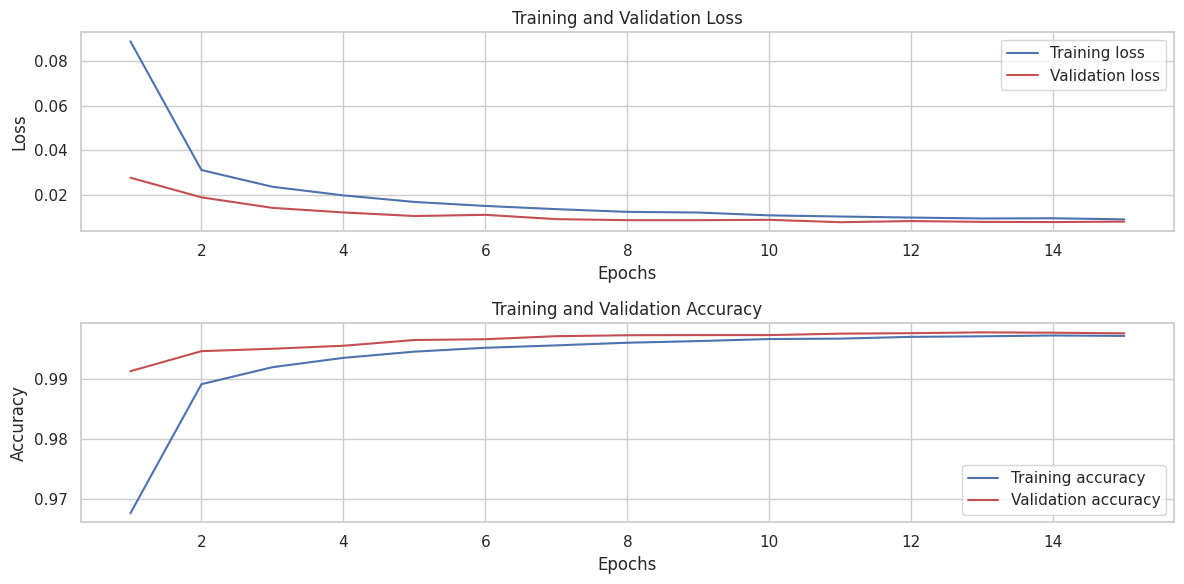

In [22]:
ep = range(1, len(history_1.history['loss']) + 1)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

sns.lineplot(x=ep, y=history_1.history['loss'], color='b', label='Training loss', ax=ax1)
sns.lineplot(x=ep, y=history_1.history['val_loss'], color='r', label='Validation loss', ax=ax1)
ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss'); ax1.set_title('Training and Validation Loss')

sns.lineplot(x=ep, y=history_1.history['accuracy'], color='b', label='Training accuracy', ax=ax2)
sns.lineplot(x=ep, y=history_1.history['val_accuracy'], color='r', label='Validation accuracy', ax=ax2)
ax2.set_xlabel('Epochs'); ax2.set_ylabel('Accuracy'); ax2.set_title('Training and Validation Accuracy')

plt.tight_layout()
plt.show()

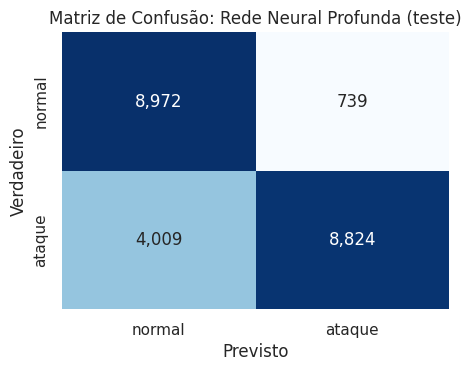

Ataques não detectados (FN): 4.009 | Alarmes falsos (FP): 739
              precision    recall  f1-score   support

      normal      0.691     0.924     0.791      9711
      ataque      0.923     0.688     0.788     12833

    accuracy                          0.789     22544
   macro avg      0.807     0.806     0.789     22544
weighted avg      0.823     0.789     0.789     22544



In [23]:
# Avaliação da rede neural nos três conjuntos
for conj, X, y in [('treino', X_tr, y_tr), ('validação', X_val, y_val), ('teste', X_te, y_te)]:
    proba = model.predict(X, verbose=0).ravel()
    avaliar('Rede Neural Profunda (MLP)', y, (proba >= 0.5).astype(int), proba, conjunto=conj)
prob_teste['Rede Neural Profunda (MLP)'] = model.predict(X_te, verbose=0).ravel()

pred_dl = (prob_teste['Rede Neural Profunda (MLP)'] >= 0.5).astype(int)
plot_matriz(y_te, pred_dl, 'Matriz de Confusão: Rede Neural Profunda (teste)')
print(classification_report(y_te, pred_dl, target_names=['normal', 'ataque'], digits=3))

### 10.6 Comparação geral: respondendo P2 e P3

In [24]:
tab = pd.DataFrame(resultados)
ordem_modelos = ['Regra booleana (IA)', 'Naive Bayes', 'Regressão Logística', 'Árvore de Decisão',
                 'Random Forest', 'Perceptron', 'Rede Neural Profunda (MLP)']
nivel = {'Regra booleana (IA)': 'IA', 'Naive Bayes': 'ML', 'Regressão Logística': 'ML',
         'Árvore de Decisão': 'ML', 'Random Forest': 'ML', 'Perceptron': 'DL', 'Rede Neural Profunda (MLP)': 'DL'}

comp = tab[tab.conjunto == 'teste'].set_index('modelo').loc[ordem_modelos, ['acurácia', 'precisão', 'recall', 'f1', 'auc']]
comp.insert(0, 'nível', comp.index.map(nivel))
f1_val = tab[tab.conjunto == 'validação'].set_index('modelo')['f1']
comp['f1 validação'] = f1_val.reindex(comp.index)
comp['queda de F1 (val → teste)'] = comp['f1 validação'] - comp['f1']
comp['meta P2 (recall e precisão ≥ 0,90)'] = np.where((comp['recall'] >= 0.9) & (comp['precisão'] >= 0.9), 'atingida', 'não atingida')
print('Desempenho no TESTE (KDDTest+), limiar padrão 0,5')
comp.round(3)

Desempenho no TESTE (KDDTest+), limiar padrão 0,5


,nível,acurácia,precisão,recall,f1,auc,f1 validação,queda de F1 (val → teste),"meta P2 (recall e precisão ≥ 0,90)"
modelo,,,,,,,,,
Regra booleana (IA),IA,0.714,0.981,0.507,0.669,NaN,0.853,0.184,não atingida
Naive Bayes,ML,0.571,0.980,0.252,0.400,0.797,0.822,0.422,não atingida
Regressão Logística,ML,0.751,0.914,0.621,0.739,0.785,0.971,0.232,não atingida
Árvore de Decisão,ML,0.817,0.925,0.739,0.822,0.830,0.998,0.177,não atingida
Random Forest,ML,0.766,0.968,0.610,0.748,0.957,0.999,0.250,não atingida
Perceptron,DL,0.757,0.899,0.646,0.751,0.722,0.964,0.212,não atingida
Rede Neural Profunda (MLP),DL,0.789,0.923,0.688,0.788,0.914,0.997,0.209,não atingida


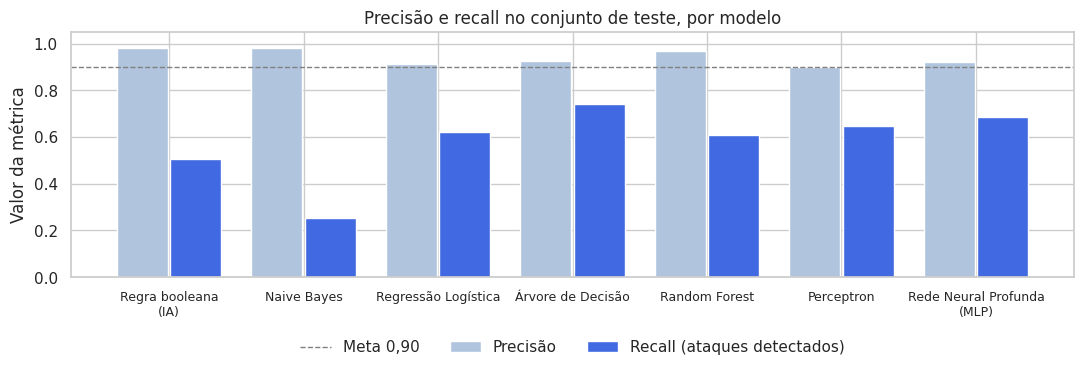

In [25]:
# Gráfico comparativo: precisão x recall no teste
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(comp))
ax.bar(x - 0.2, comp['precisão'], width=0.38, color='lightsteelblue', label='Precisão')
ax.bar(x + 0.2, comp['recall'], width=0.38, color='royalblue', label='Recall (ataques detectados)')
ax.axhline(0.9, color='gray', ls='--', lw=1, label='Meta 0,90')
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' (', '\n(') for m in comp.index], fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Valor da métrica')
ax.set_title('Precisão e recall no conjunto de teste, por modelo')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
plt.tight_layout()
plt.show()

#### Robustez: o resultado depende da "sorte" da semente aleatória?

A Árvore de Decisão e a rede neural têm componentes aleatórios (desempate de divisões, pesos iniciais, dropout). Um bom resultado com **uma** semente pode ser sorte. Repetimos o treino com várias sementes e olhamos a variação no teste.

In [26]:
rob = []
novo_mask = (df_te['ataque_novo'] == 1).values
for s in range(5):
    arv = DecisionTreeClassifier(random_state=s).fit(X_tr, y_tr)
    p = arv.predict(X_te)
    rob.append({'modelo': 'Árvore de Decisão', 'semente': s, 'f1 teste': f1_score(y_te, p), 'recall ataques novos': p[novo_mask].mean()})
for s in range(3):
    tf.keras.utils.set_random_seed(s)
    m = make_model(X_tr.shape[1])
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
    m.fit(X_tr, y_tr, epochs=epochs, batch_size=256, validation_data=(X_val, y_val),
          callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)], verbose=0)
    p = (m.predict(X_te, verbose=0).ravel() >= 0.5).astype(int)
    rob.append({'modelo': 'Rede Neural Profunda (MLP)', 'semente': s, 'f1 teste': f1_score(y_te, p), 'recall ataques novos': p[novo_mask].mean()})
tf.keras.utils.set_random_seed(SEED)

tab_rob = pd.DataFrame(rob)
tab_rob.groupby('modelo')[['f1 teste', 'recall ataques novos']].agg(['mean', 'std', 'min', 'max']).round(3)

f1 teste                      recall ataques novos  \
                               mean    std    min    max                 mean   
modelo                                                                          
Rede Neural Profunda (MLP)    0.793  0.016  0.783  0.811                0.424   
Árvore de Decisão             0.800  0.016  0.783  0.819                0.496   

                                                 
                              std    min    max  
modelo                                           
Rede Neural Profunda (MLP)  0.019  0.412  0.445  
Árvore de Decisão           0.038  0.469  0.556

#### Detecção por categoria e por ataques conhecidos x novos (P3)

Aqui está o coração da P3: separamos os ataques do teste em **conhecidos** (o tipo existe no treino) e **novos** (tipo nunca visto), e medimos quantos cada modelo detecta.

Taxa de detecção (recall) no TESTE por grupo de ataque


,ataques conhecidos,ataques novos,DoS,Probe,R2L,U2R
modelo,,,,,,
Regra booleana (IA),0.629,0.213,0.669,0.416,0.174,0.160
Naive Bayes,0.298,0.140,0.338,0.289,0.003,0.000
Regressão Logística,0.714,0.395,0.820,0.751,0.005,0.080
Árvore de Decisão,0.815,0.556,0.867,0.829,0.323,0.640
Random Forest,0.770,0.222,0.769,0.790,0.058,0.095
Perceptron,0.744,0.407,0.864,0.739,0.010,0.130
Rede Neural Profunda (MLP),0.792,0.435,0.853,0.855,0.130,0.170


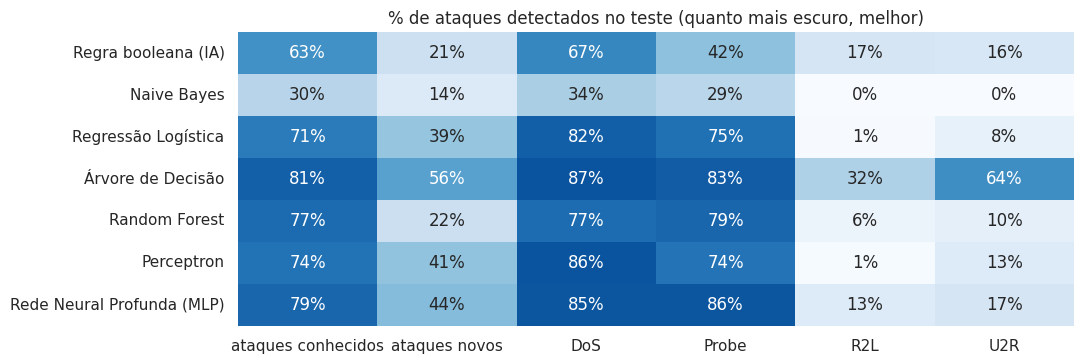

In [27]:
linhas_p3 = []
for nome in ordem_modelos:
    pred = pred_regra_te.values if nome == 'Regra booleana (IA)' else (
        ppn.predict(X_te) if nome == 'Perceptron' else (prob_teste[nome] >= 0.5).astype(int))
    d = df_te.assign(pred=pred)
    at = d[d.alvo == 1]
    linha = {'modelo': nome,
             'ataques conhecidos': at[at.ataque_novo == 0]['pred'].mean(),
             'ataques novos': at[at.ataque_novo == 1]['pred'].mean()}
    for cat in ordem_cat:
        linha[cat] = at[at.categoria_ataque == cat]['pred'].mean()
    linhas_p3.append(linha)

det = pd.DataFrame(linhas_p3).set_index('modelo')
print('Taxa de detecção (recall) no TESTE por grupo de ataque')
display(det.round(3))

fig, ax = plt.subplots(figsize=(11, 3.8))
sns.heatmap(det, annot=True, fmt='.0%', cmap='Blues', vmin=0, vmax=1, cbar=False, ax=ax)
ax.set_title('% de ataques detectados no teste (quanto mais escuro, melhor)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Um limite dos próprios dados:** alguns ataques novos são, nas 41 variáveis, **idênticos** a conexões normais. A célula abaixo conta quantos ataques do teste têm exatamente o mesmo vetor de atributos de alguma conexão normal. Nesses casos, **nenhum** modelo consegue acertar, porque a informação que distinguiria o ataque simplesmente não está na tabela.

In [28]:
feats = [c for c in COLUNAS if c not in ['label', 'difficulty']]
chaves_normais = set(map(tuple, df_teste_bruto.loc[df_teste_bruto.label == 'normal', feats].values))
at_bruto = df_teste_bruto[df_teste_bruto.label != 'normal']
identicos = at_bruto[feats].apply(tuple, axis=1).isin(chaves_normais)
print(f'Ataques do teste idênticos a alguma conexão normal: {identicos.sum()} de {len(at_bruto)}')
print(at_bruto.loc[identicos, 'label'].value_counts())

Ataques do teste idênticos a alguma conexão normal: 54 de 12833
label
snmpgetattack    54
Name: count, dtype: int64


## 11. Explicabilidade e decisão

### P4. Quais características da conexão mais pesam na detecção?

Usamos a **importância das variáveis** do Random Forest: quanto uma variável ajuda, em média, a separar normal de ataque nas árvores. Isso dá ao analista uma lista do que olhar primeiro.

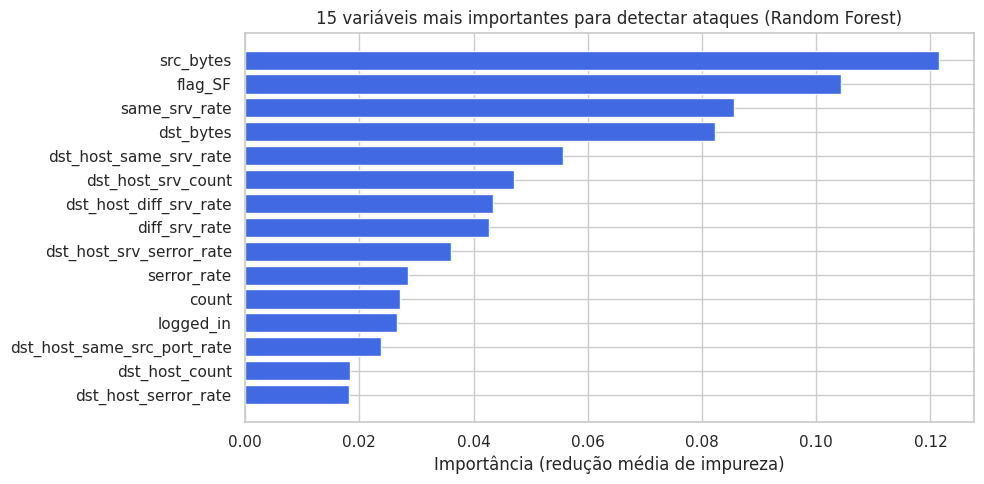

,importância,descrição
src_bytes,0.1215,Bytes enviados da origem para o destino
flag_SF,0.1044,"Estado final da conexão TCP (SF = normal, S0 = sem resposta, REJ = rejeitada...)"
same_srv_rate,0.0856,"% de conexões para o mesmo serviço (mesmo host, 2 s)"
dst_bytes,0.0823,Bytes enviados do destino para a origem
dst_host_same_srv_rate,0.0556,"% para o mesmo serviço (últimas 100, mesmo host)"
dst_host_srv_count,0.0471,Conexões para o mesmo serviço de destino (últimas 100)
dst_host_diff_srv_rate,0.0434,"% para serviços diferentes (últimas 100, mesmo host)"
diff_srv_rate,0.0427,"% de conexões para serviços diferentes (mesmo host, 2 s)"
dst_host_srv_serror_rate,0.0360,"% com erro SYN (últimas 100, mesmo serviço)"
serror_rate,0.0284,"% de conexões com erro SYN (mesmo host, 2 s)"


In [29]:
rf = modelos_ml['Random Forest']
imp = pd.Series(rf.feature_importances_, index=[n.split('__')[1] for n in nomes_features])
top_imp = imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_imp.index[::-1], top_imp.values[::-1], color='royalblue')
ax.set_xlabel('Importância (redução média de impureza)')
ax.set_title('15 variáveis mais importantes para detectar ataques (Random Forest)')
plt.tight_layout()
plt.show()

top_tab = top_imp.to_frame('importância').round(4)
top_tab['descrição'] = [DESCRICOES.get(c, DESCRICOES.get(c.split('_')[0], 'categoria de ' + c.split('_')[0])) for c in top_imp.index]
top_tab

**Entendendo P4:** as variáveis mais importantes são, em geral, os **bytes trocados** (`src_bytes`, `dst_bytes`), as **taxas de erro e de repetição de serviço** e a **flag** da conexão. Traduzindo para o analista: *"quanto dado a conexão trocou, se ela foi completada e se faz parte de uma rajada repetitiva"*. Isso confirma, com dados, a intuição por trás da regra booleana, mas o modelo encontrou **combinações e limiares** que o especialista não tinha escrito.

**Decisão apoiada:** garantir que os logs de rede capturem volume de bytes, estado da conexão (flag) e janelas de contagem de conexões; sem esses campos, qualquer modelo perde a maior parte do poder de detecção.

### P5. Qual limiar de decisão minimiza o custo esperado dos erros?

Até aqui usamos o limiar padrão: se a probabilidade de ataque ≥ 0,5, marca como ataque. Mas **os erros não custam o mesmo**:

| Erro | Consequência | Custo relativo (premissa) |
|---|---|---|
| Falso Negativo (ataque não detectado) | Invasão, vazamento, indisponibilidade | **10** |
| Falso Positivo (alarme falso) | Tempo do analista investigando | **1** |

> A proporção 10 para 1 é uma **premissa** do trabalho, coerente com a literatura de custo de incidentes (um vazamento custa ordens de grandeza mais do que uma triagem). Testamos também 5 e 20 para ver se a conclusão muda (análise de sensibilidade).

**Cuidado metodológico:** se escolhêssemos o limiar olhando o próprio teste e depois medíssemos no teste, estaríamos "colando". Por isso dividimos o teste ao meio: a **metade de calibração** escolhe o limiar e a **metade de avaliação** mede o resultado honestamente. Pense assim: usamos a primeira semana do mês novo para ajustar a régua e conferimos na segunda semana.

In [30]:
from sklearn.model_selection import train_test_split as tts

idx = np.arange(len(y_te))
idx_cal, idx_ava = tts(idx, test_size=0.5, random_state=SEED, stratify=df_te['categoria_ataque'])

CUSTO_FN, CUSTO_FP = 10, 1
# Grade de limiares: bem fina perto de zero (escala log) e mais espaçada até 0,95
limiares = np.unique(np.concatenate([np.logspace(-5, -1, 161), np.arange(0.1, 0.951, 0.01)]))

def melhor_limiar(custos):
    # Entre limiares de mesmo custo mínimo, escolhe o MAIOR (mais conservador)
    return np.where(custos == custos.min())[0][-1]

def custo(y, proba, lim, cfn=CUSTO_FN, cfp=CUSTO_FP):
    pred = (proba >= lim).astype(int)
    fn = int(((pred == 0) & (y == 1)).sum()); fp = int(((pred == 1) & (y == 0)).sum())
    return cfn * fn + cfp * fp

linhas_p5, curvas = [], {}
for nome in ['Regressão Logística', 'Random Forest', 'Rede Neural Profunda (MLP)']:
    p = prob_teste[nome]
    custos_cal = np.array([custo(y_te[idx_cal], p[idx_cal], l) for l in limiares])
    curvas[nome] = custos_cal
    lim_otimo = limiares[melhor_limiar(custos_cal)]
    for rotulo, lim in [('0,5 (padrão)', 0.5), ('ótimo', lim_otimo)]:
        pred = (p[idx_ava] >= lim).astype(int)
        linhas_p5.append({'modelo': nome, 'limiar': rotulo, 'valor do limiar': lim,
                          'recall': recall_score(y_te[idx_ava], pred),
                          'precisão': precision_score(y_te[idx_ava], pred),
                          'custo (avaliação)': custo(y_te[idx_ava], p[idx_ava], lim)})
tab_p5 = pd.DataFrame(linhas_p5)
tab_p5['redução de custo'] = tab_p5.groupby('modelo')['custo (avaliação)'].transform(lambda s: 1 - s / s.iloc[0])
print(f'Custo FN = {CUSTO_FN}, custo FP = {CUSTO_FP}. Resultados medidos na METADE DE AVALIAÇÃO do teste.')
tab_p5.round({'recall': 3, 'precisão': 3, 'redução de custo': 3, 'valor do limiar': 5})

Custo FN = 10, custo FP = 1. Resultados medidos na METADE DE AVALIAÇÃO do teste.


,modelo,limiar,valor do limiar,recall,precisão,custo (avaliação),redução de custo
0,Regressão Logística,"0,5 (padrão)",0.50000,0.618,0.916,24875,0.000
1,Regressão Logística,ótimo,0.00001,0.939,0.555,8726,0.649
2,Random Forest,"0,5 (padrão)",0.50000,0.608,0.967,25283,0.000
3,Random Forest,ótimo,0.01000,0.980,0.892,2054,0.919
4,Rede Neural Profunda (MLP),"0,5 (padrão)",0.50000,0.687,0.923,20436,0.000
5,Rede Neural Profunda (MLP),ótimo,0.00001,0.938,0.847,5048,0.753


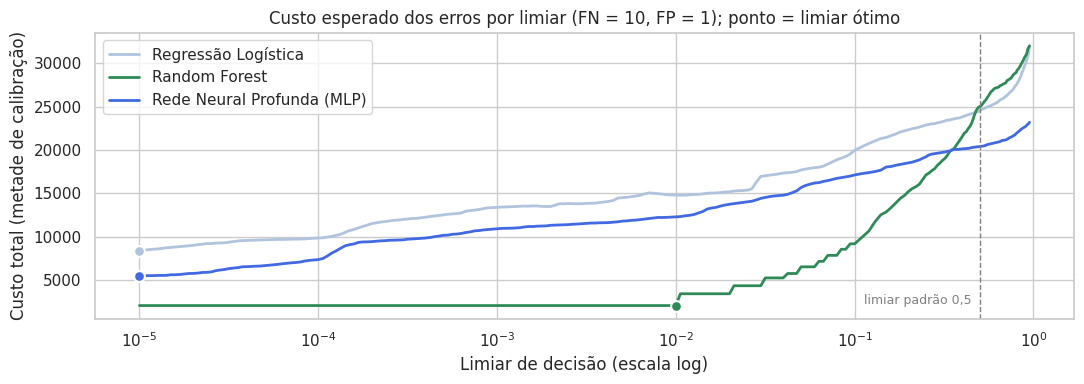

In [31]:
fig, ax = plt.subplots(figsize=(11, 4))
cores = {'Regressão Logística': 'lightsteelblue', 'Random Forest': 'seagreen', 'Rede Neural Profunda (MLP)': 'royalblue'}
for nome, c in curvas.items():
    ax.plot(limiares, c, color=cores[nome], lw=2, label=nome)
    i = melhor_limiar(c)
    ax.scatter(limiares[i], c[i], color=cores[nome], s=60, zorder=3, edgecolor='white', linewidth=1.5)
ax.axvline(0.5, color='gray', ls='--', lw=1)
ax.text(0.45, ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]), 'limiar padrão 0,5', color='gray', fontsize=9, ha='right')
ax.set_xscale('log')
ax.set_xlabel('Limiar de decisão (escala log)')
ax.set_ylabel('Custo total (metade de calibração)')
ax.set_title('Custo esperado dos erros por limiar (FN = 10, FP = 1); ponto = limiar ótimo')
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
# Análise de sensibilidade: o limiar ótimo muda muito se o custo do FN for 5 ou 20?
melhor_p5 = tab_p5[tab_p5.limiar == 'ótimo'].sort_values('custo (avaliação)').iloc[0]['modelo']
p = prob_teste[melhor_p5]
sens = []
for cfn in [5, 10, 20]:
    cs = np.array([custo(y_te[idx_cal], p[idx_cal], l, cfn=cfn) for l in limiares])
    lim = limiares[melhor_limiar(cs)]
    pred = (p[idx_ava] >= lim).astype(int)
    sens.append({'custo FN': cfn, 'limiar ótimo': lim,
                 'recall': recall_score(y_te[idx_ava], pred), 'precisão': precision_score(y_te[idx_ava], pred)})
print('Modelo com menor custo na avaliação:', melhor_p5)
pd.DataFrame(sens).round({'recall': 3, 'precisão': 3, 'limiar ótimo': 5})

Modelo com menor custo na avaliação: Random Forest


,custo FN,limiar ótimo,recall,precisão
0,5,0.01,0.98,0.892
1,10,0.01,0.98,0.892
2,20,0.01,0.98,0.892


### 11.1 O Sistema de Suporte à Decisão: política de ação em três faixas

Com as probabilidades do melhor modelo, transformamos a saída numa **recomendação de ação** para o analista. Em vez de um "sim ou não", usamos três faixas:

| Faixa de probabilidade de ataque | Ação recomendada |
|---|---|
| ≥ 0,90 | 🔴 **BLOQUEAR** automaticamente e registrar |
| entre o limiar ótimo e 0,90 | 🟡 **INVESTIGAR**: vai para a fila do analista |
| abaixo do limiar ótimo | 🟢 **LIBERAR** |

A tabela abaixo mostra, na metade de avaliação do teste, quanto trabalho cada faixa gera e quão "pura" ela é. É isso que um gestor de segurança usa para dimensionar a equipe.

In [33]:
lim_inv = float(tab_p5[(tab_p5.modelo == melhor_p5) & (tab_p5.limiar == 'ótimo')]['valor do limiar'].iloc[0])
LIM_BLOQ = 0.90

def acao(prob):
    return np.where(prob >= LIM_BLOQ, '1 BLOQUEAR', np.where(prob >= lim_inv, '2 INVESTIGAR', '3 LIBERAR'))

d_ava = df_te.iloc[idx_ava].assign(prob=prob_teste[melhor_p5][idx_ava])
d_ava['ação'] = acao(d_ava['prob'].values)

politica = d_ava.groupby('ação').agg(conexoes=('alvo', 'size'), ataques=('alvo', 'sum'))
politica['% das conexões'] = politica['conexoes'] / politica['conexoes'].sum() * 100
politica['% que são ataque'] = politica['ataques'] / politica['conexoes'] * 100
politica['% de todos os ataques'] = politica['ataques'] / politica['ataques'].sum() * 100
print(f'Modelo: {melhor_p5} | limiar INVESTIGAR = {lim_inv} | limiar BLOQUEAR = {LIM_BLOQ}')
politica.round(1)

Modelo: Random Forest | limiar INVESTIGAR = 0.01 | limiar BLOQUEAR = 0.9


,conexoes,ataques,% das conexões,% que são ataque,% de todos os ataques
ação,,,,,
1 BLOQUEAR,3392,3286,30.1,96.9,51.2
2 INVESTIGAR,3659,3001,32.5,82.0,46.8
3 LIBERAR,4221,129,37.4,3.1,2.0


In [34]:
# Demonstração: o SSD recomendando ação para 6 conexões reais do teste
amostra = pd.concat([g.sample(min(len(g), 2), random_state=SEED) for _, g in d_ava.groupby('ação')])
amostra[['protocol_type', 'service', 'flag', 'serror_rate', 'count', 'label', 'prob', 'ação']].rename(
    columns={'label': 'rótulo real', 'prob': 'prob. ataque'}).round(3)

,protocol_type,service,flag,serror_rate,count,rótulo real,prob. ataque,ação
17462,tcp,vmnet,REJ,0.0,249,neptune,1.00,1 BLOQUEAR
4507,tcp,private,RSTR,0.0,1,portsweep,1.00,1 BLOQUEAR
304,udp,private,SF,0.0,279,normal,0.21,2 INVESTIGAR
671,udp,other,SF,0.0,145,satan,0.79,2 INVESTIGAR
18101,tcp,http,SF,0.0,14,normal,0.00,3 LIBERAR
5192,tcp,http,SF,0.0,1,normal,0.00,3 LIBERAR


In [35]:
# Camada gold: resultados prontos para decisão, persistidos na nuvem
comp.round(4).to_csv(f'{PASTA_BASE}/gold/comparacao_modelos_teste.csv')
det.round(4).to_csv(f'{PASTA_BASE}/gold/deteccao_por_categoria.csv')
tab_p5.round(4).to_csv(f'{PASTA_BASE}/gold/limiar_otimo_custo.csv', index=False)
politica.round(2).to_csv(f'{PASTA_BASE}/gold/politica_de_acao.csv')
model.save(f'{PASTA_BASE}/gold/modelo_mlp.keras')

for camada in ['bronze', 'silver', 'gold']:
    print(camada, '->', sorted(os.listdir(f'{PASTA_BASE}/{camada}')))

bronze -> ['KDDTest+.csv', 'KDDTrain+.csv']
silver -> ['catalogo_dados.csv', 'tb_conexoes.parquet']
gold -> ['comparacao_modelos_teste.csv', 'deteccao_por_categoria.csv', 'limiar_otimo_custo.csv', 'modelo_mlp.keras', 'politica_de_acao.csv']


### 11.2 Sincronização com o Google Drive

O Colab grava no Drive de forma assíncrona. A célula abaixo força o envio de todos os arquivos para a nuvem antes de encerrar a sessão. Depois dela, a pasta **Meu Drive > MVP_SSD_Seguranca** aparece completa no Google Drive.

In [36]:
# Força a gravação dos arquivos no Google Drive (só tem efeito no Colab)
if NO_COLAB:
    drive.flush_and_unmount()
    print('Arquivos sincronizados com o Google Drive.')
else:
    print('Fora do Colab: arquivos salvos em', os.path.abspath(PASTA_BASE))

Arquivos sincronizados com o Google Drive.


## 12. Discussão geral

> Os números abaixo são os da execução registrada neste notebook. Ao reexecutar no Colab (principalmente com GPU), a rede neural pode variar alguns décimos, mas as conclusões se mantêm (ver a análise de robustez).

### Respostas às perguntas de negócio

| # | Resposta curta | Evidência |
|---|---|---|
| P1 | **DoS domina o volume** (78% dos ataques no treino, 58% no teste), concentrado no serviço `private` e com flag S0 (SYN flood). ICMP é o protocolo mais "sujo" (85% das conexões ICMP são ataque). No teste, **R2L salta de 1,7% para 21,5%** dos ataques. | Seção 9 |
| P2 | **Parcialmente.** Com o limiar padrão (0,5), nenhum modelo atinge a meta: o melhor F1 é da Árvore de Decisão (0,822; recall 0,739). Mas todos os modelos de ML, exceto o Naive Bayes, superam a regra booleana (F1 0,669, recall 0,507). Com o limiar ajustado por custo (P5), o Random Forest chega a **recall 0,980 e precisão 0,892**, praticamente sobre a meta. | Seções 10.3, 10.4, 10.6 e 11 |
| P3 | **Não, neste MVP.** A rede neural profunda tem AUC alta (cerca de 0,91), mas **não supera a Árvore de Decisão**: nem no F1 médio entre sementes (cerca de 0,79 contra 0,80) nem em ataques novos (cerca de 42% contra 50% detectados). A hipótese de que o DL generaliza melhor para ataques desconhecidos foi **refutada** para esta base e esta arquitetura. | Seção 10.6 (tabela, robustez e mapa de calor) |
| P4 | As variáveis que mais pesam são **bytes enviados e recebidos**, **flag SF** (conexão completada normalmente) e as **taxas de repetição de serviço** (`same_srv_rate`, `dst_host_same_srv_rate`). Ou seja: volume, estado da conexão e padrão repetitivo. | Seção 11, P4 |
| P5 | Com custo de FN 10 vezes o de FP, o limiar ótimo é **muito menor que 0,5**. Para o Random Forest, basta que **1 das 100 árvores** vote "ataque" (limiar 0,01): o custo total cai **92%** e a conclusão é a mesma para custos de 5 ou 20. | Seção 11, P5 |

### O que aprendemos (a conexão entre as respostas)

**1. Validação alta não garante desempenho real.** Na validação, quase todos os modelos passam de 97% de F1, e a validação cruzada confirma que são estáveis. No teste, todos caem entre 18 e 42 pontos. A causa não é o overfitting clássico (as curvas de treino e validação da rede neural andam juntas), e sim a **mudança de distribuição**: 29% dos ataques do teste são de tipos que não existem no treino, e a categoria R2L passa de rara a relevante. Em segurança, este é o cenário normal: o atacante se adapta.

**2. Mais complexidade não é automaticamente melhor.** Subindo do nível IA para ML e DL, o ganho é claro em relação à regra manual (o recall sobe de 51% para até 74%). Mas, dentro de ML e DL, a Árvore de Decisão, que é o modelo mais simples e mais explicável, detecta mais ataques novos do que a rede neural e o Random Forest. A rede neural e o Random Forest ajustam fronteiras muito bem ao treino e, por isso, ficam **confiantes demais** de que o tráfego novo é normal.

**3. O limiar é uma decisão de negócio, não um detalhe técnico.** O Random Forest tem a melhor capacidade de ordenar conexões por risco (AUC 0,957), mas com o limiar padrão deixa passar 39% dos ataques. Quando o limiar reflete o custo real dos erros, ele se torna o melhor modelo. Isso mostra o papel do SSD: o algoritmo gera a probabilidade, **a regra de decisão é definida pelo gestor** a partir dos custos.

**4. Há um teto imposto pelos dados.** 54 conexões `snmpgetattack` (30% desse tipo de ataque) são idênticas, atributo por atributo, a conexões normais. Nenhum modelo acerta esses casos; seria preciso coletar outras informações (conteúdo do pacote, reputação do IP, horário).

### Recomendação do SSD

Adotar o **Random Forest com política de três faixas**. Na metade de avaliação do teste:

| Ação | % das conexões | % que são ataque | % de todos os ataques |
|---|---|---|---|
| 🔴 BLOQUEAR (prob. ≥ 0,90) | 30,1% | 96,9% | 51,2% |
| 🟡 INVESTIGAR (0,01 ≤ prob. < 0,90) | 32,5% | 82,0% | 46,8% |
| 🟢 LIBERAR (prob. < 0,01) | 37,4% | 3,1% | 2,0% |

Metade dos ataques é bloqueada automaticamente com quase nenhum falso alarme; a fila do analista fica com um terço do tráfego, em que 4 de cada 5 itens são ataques reais; e apenas **2% dos ataques** escapam. Como a Árvore de Decisão pega mais ataques novos, uma extensão natural é usá-la como **segunda opinião** na faixa LIBERAR.

## 13. Autoavaliação

**1. Quais perguntas foram respondidas e quais não foram? Por quê?**

P1, P4 e P5 foram respondidas integralmente. P2 foi **parcialmente** atingida: com o limiar padrão nenhum modelo alcança recall e precisão de 90% ao mesmo tempo; só com o limiar ajustado por custo o Random Forest chega perto (recall 98,0%, precisão 89,2%, apenas 0,8 ponto abaixo da meta de precisão). P3 foi respondida, mas com resultado **negativo**: a rede neural não generalizou melhor para ataques novos. Mantive as perguntas intactas, porque o resultado negativo é, em si, um aprendizado útil para quem decide investir em Deep Learning.

**2. Que limitações dos dados condicionaram os resultados?**

* A NSL-KDD foi gerada em laboratório a partir de tráfego de 1998; os padrões de ataque atuais (ransomware, ataques a APIs, tráfego criptografado) são diferentes.
* O treino tem pouquíssimos exemplos de R2L e U2R (52 conexões U2R), o que limita o aprendizado dessas categorias.
* Alguns ataques são indistinguíveis de tráfego normal com as 41 variáveis disponíveis.
* Para ajustar o limiar sem vazamento, usei metade do conjunto de teste para calibração, o que reduz o tamanho da amostra de avaliação final.
* O custo 10 para 1 entre FN e FP é uma premissa; a análise de sensibilidade mostrou que a conclusão não muda entre 5 e 20.

**3. Quais decisões técnicas eu tomaria de outra forma?**

* Testaria a rede neural com **pesos de classe** e com uma camada de *embedding* para `service`, em vez de One-Hot.
* Faria a calibração do limiar com uma base temporal separada (por exemplo, a semana seguinte), em vez de dividir o teste.
* Incluiria uma base mais recente (CIC-IDS2017 ou UNSW-NB15) para verificar se as conclusões se repetem.

**4. Que extensões transformariam este MVP em uma solução de uso contínuo?**

* **Retreino periódico** com os ataques confirmados pelos analistas na faixa INVESTIGAR (aprendizado contínuo), já que o problema central é a mudança de distribuição.
* **Detecção de anomalias** (por exemplo, *autoencoder*, outra técnica de Deep Learning) para sinalizar tráfego "diferente de tudo" mesmo sem rótulo.
* Pipeline agendado (Databricks ou Colab + Drive) lendo logs reais, com painel de acompanhamento do volume em cada faixa e alerta quando a taxa de ataques liberados subir.
* Explicação por conexão (por exemplo, SHAP) para que o analista veja o motivo de cada alerta.

## 14. Referências

* TAVALLAEE, M.; BAGHERI, E.; LU, W.; GHORBANI, A. A. *A Detailed Analysis of the KDD CUP 99 Data Set*. IEEE Symposium on Computational Intelligence for Security and Defense Applications (CISDA), 2009.
* Canadian Institute for Cybersecurity. *NSL-KDD dataset*. https://www.unb.ca/cic/datasets/nsl.html
* SERRANO, A. L. M. *Demonstração de implementações de Inteligência Artificial com Deep Learning* (notebook de aula), UnB, 2026.
* Scikit-learn: https://scikit-learn.org | TensorFlow/Keras: https://www.tensorflow.org | PyPI: https://pypi.org
* IBM Security. *Cost of a Data Breach Report* (referência para a premissa de assimetria de custos entre FN e FP).